# Notebook 03 — Exploratory Data Analysis
Understand distributions, relationships, and patterns before modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED = '../data/processed/'
proj  = pd.read_csv(PROCESSED + 'cleaned_project_level.csv',  low_memory=False)
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Project-level: ', proj.shape)
print('Disaster-level:', disas.shape)


Project-level:  (809734, 33)
Disaster-level: (1766, 20)


## 3.1 Class Balance — Funding Tier Distribution
This plot shows how many projects/disasters fall into each funding tier.
Class imbalance here directly informs whether we need `class_weight='balanced'` in modeling.

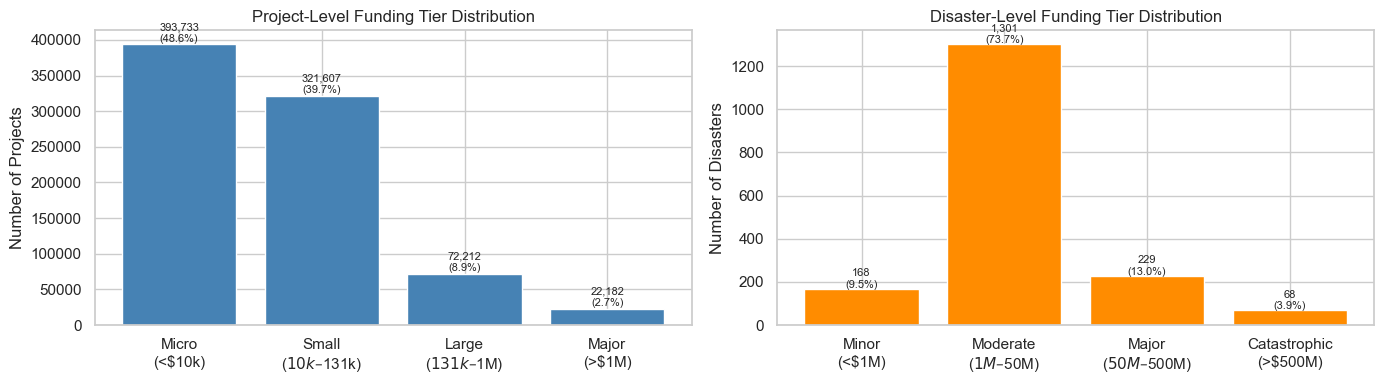

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Project-level tier distribution
tier_labels = ['Micro\n(<$10k)', 'Small\n($10k–$131k)', 'Large\n($131k–$1M)', 'Major\n(>$1M)']
counts_proj = proj['funding_tier'].value_counts().sort_index()
axes[0].bar(tier_labels, counts_proj.values, color='steelblue', edgecolor='white')
axes[0].set_title('Project-Level Funding Tier Distribution')
axes[0].set_ylabel('Number of Projects')
for i, v in enumerate(counts_proj.values):
    axes[0].text(i, v + 4000, f'{v:,}\n({100*v/len(proj):.1f}%)', ha='center', fontsize=8)

# Disaster-level tier distribution
dis_labels = ['Minor\n(<$1M)', 'Moderate\n($1M–$50M)', 'Major\n($50M–$500M)', 'Catastrophic\n(>$500M)']
counts_dis = disas['funding_tier'].value_counts().sort_index()
axes[1].bar(dis_labels, counts_dis.values, color='darkorange', edgecolor='white')
axes[1].set_title('Disaster-Level Funding Tier Distribution')
axes[1].set_ylabel('Number of Disasters')
for i, v in enumerate(counts_dis.values):
    axes[1].text(i, v + 5, f'{v:,}\n({100*v/len(disas):.1f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/eda_class_balance.png', dpi=150)
plt.show()

## 3.2 Mean Total Federal Share by Incident Type (Disaster-Level)

In [ ]:
avg_by_type = (
    disas.groupby('incidentType')['total_federal_share']
    .mean()
    .sort_values(ascending=False)
)
avg_by_type.plot(kind='barh', figsize=(10, 5), color='steelblue',
                 title='Mean Total Federal Share by Incident Type (Disaster-Level)')
plt.xlabel('Mean Total Federal Share ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3.3 Funding Tier Distribution by Incident Type (Disaster-Level)
Shows which incident types tend to produce higher-tier disasters — directly validates
`incidentType` as a predictive feature in the model.

In [ ]:
tier_map = {0: 'Minor', 1: 'Moderate', 2: 'Major', 3: 'Catastrophic'}

ct = (disas.groupby(['incidentType', 'funding_tier'])
          .size()
          .unstack(fill_value=0))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.columns = [tier_map[c] for c in ct_pct.columns]

ct_pct.plot(kind='bar', stacked=True, figsize=(12, 5),
            colormap='RdYlGn', edgecolor='white')
plt.title('Disaster Funding Tier Distribution by Incident Type (%)')
plt.ylabel('% of Disasters')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3.4 Total Federal Obligations by Year


In [ ]:
yearly = disas.groupby('incident_year')['total_federal_share'].sum() / 1e9
yearly.plot(kind='bar', figsize=(13, 4), color='steelblue', edgecolor='white',
            title='Total Federal PA Obligations by Year — Disaster-Level (Billions $)')
plt.ylabel('Total Federal Share ($B)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.5 Disaster Funding Tier Distribution by Season

In [ ]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
tier_map = {0: 'Minor', 1: 'Moderate', 2: 'Major', 3: 'Catastrophic'}

ct = (disas.groupby(['incident_season', 'funding_tier'])
          .size()
          .unstack(fill_value=0)
          .loc[[s for s in season_order if s in disas['incident_season'].unique()]])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.columns = [tier_map[c] for c in ct_pct.columns]

ct_pct.plot(kind='bar', stacked=True, figsize=(9, 4),
            colormap='Set2', edgecolor='white')
plt.title('Disaster Funding Tier Distribution by Season (%)')
plt.ylabel('% of Disasters')
plt.xticks(rotation=0)
plt.legend(title='Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3.6 Correlation Heatmap (Numeric Features)


In [ ]:
num_cols = ['declaration_lag_days', 'incident_duration_days', 'n_counties',
            'prior_disasters_5yr', 'population', 'median_income', 'poverty_rate', 'risk_score']
num_cols = [c for c in num_cols if c in disas.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(disas[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Disaster-Level Numeric Features')
plt.tight_layout()
plt.show()

## 3.7 Top 10 States by Total Obligation


In [ ]:
top_states = (
    disas.groupby('stateAbbreviation')['total_federal_share']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    / 1e9
)
top_states.plot(kind='bar', figsize=(10, 4), color='steelblue', edgecolor='white',
                title='Top 10 States — Total Federal PA Obligations ($B, Disaster-Level)')
plt.ylabel('Total ($B)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.8 Missing Data Summary


In [ ]:
missing = disas.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    print('Remaining nulls in disaster-level data:')
    print(missing)
else:
    print('No nulls remaining in disaster-level data. ✓')